# Magnetic flux loops PCA notebook

Notebook demonstrating performing principal component analysis on magnetic flux loop data.

Get all shot numbers

In [1]:
import fsspec

local_path = f"/rds/project/rds-mOlK9qn0PlQ/fairmast/upload-tmp/level2/"
fs = fsspec.filesystem('file')

# List all files and folders in the base path
all_files = fs.ls(local_path)

# Extract shot_id from the filenames
shot_ids = [file.split('/')[-1].replace('.zarr', '') for file in all_files]

# Convert them to integers
shot_ids = [int(shot_id) for shot_id in shot_ids if shot_id.isdigit()]

print(len(shot_ids))

2


Define some utility functions

In [2]:
import xarray as xr
import zarr

def get_shot_fsstore(shot_id):
    local_path = f"/rds/project/rds-mOlK9qn0PlQ/fairmast/upload-tmp/level2/{shot_id}.zarr"
    if zarr.__version__[0] == "2":
        store = zarr.storage.FSStore(fs=fsspec.filesystem('file'), url=local_path, check=False)
    else:
        store = zarr.storage.LocalStore(root=local_path)
    
    return store


def get_flux_loop(shot_id):
    store = get_shot_fsstore(shot_id)
    profiles = xr.open_zarr(store, group="magnetics")
    flux_loop = profiles["flux_loop_flux"]
    return flux_loop

Iterate over some random shot IDs and plot flux loop profiles

  0%|          | 0/2 [00:00<?, ?it/s]

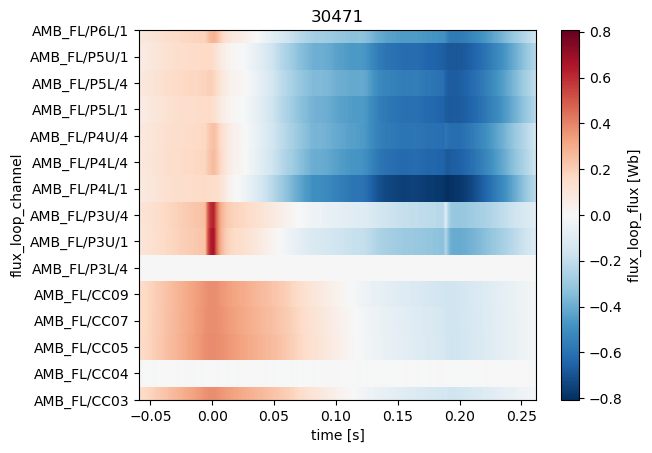

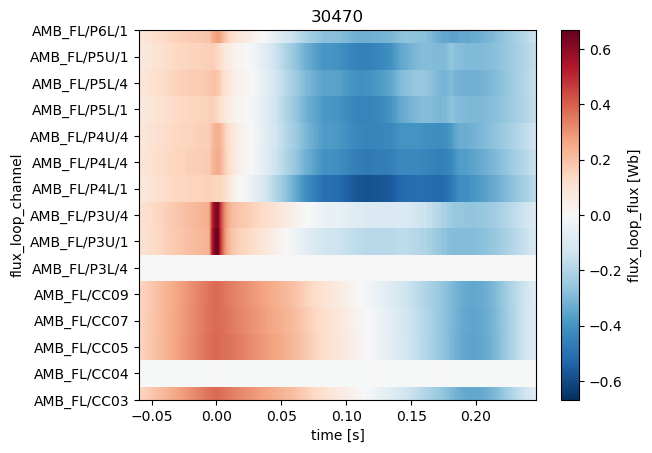

In [3]:
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm

random.seed(42)
random.shuffle(shot_ids)
random_shot_ids = shot_ids[:10]

for shot_id in tqdm(random_shot_ids):
    flux_loop = get_flux_loop(shot_id)
    fig, ax = plt.subplots()
    flux_loop.plot(ax=ax)
    ax.set_title(shot_id)

Inspect an interesting shot

[0.00022093 0.00034801 0.00034815 ... 0.00031168 0.00031182 0.00018501]
[ 0.08014611  0.08051784  0.08101346 ... -0.16323532 -0.16162466
 -0.15989009]


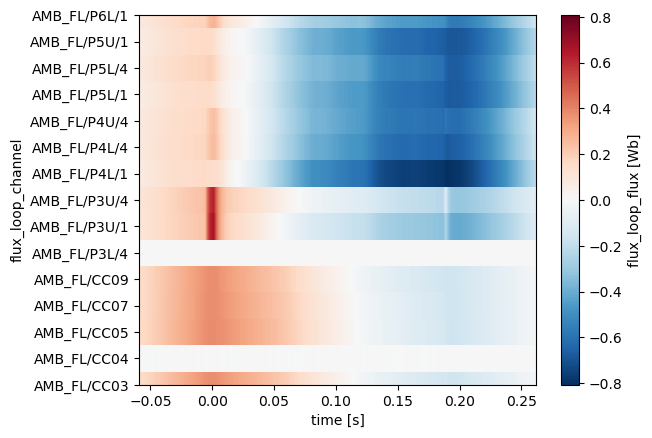

In [4]:
flux_loop = get_flux_loop(30471)

fig, ax = plt.subplots()
flux_loop.plot(ax=ax)
print(flux_loop.sel(flux_loop_channel="AMB_FL/P3L/4").values)
print(flux_loop.sel(flux_loop_channel="AMB_FL/P6L/1").values)

PCA does not work with NaN values, so these must be imputed. Demonstrated here is imputation of NaN flux loop channel values as the mean across non-NaN channel values at the same time index.

Text(0.5, 1.0, 'Imputed')

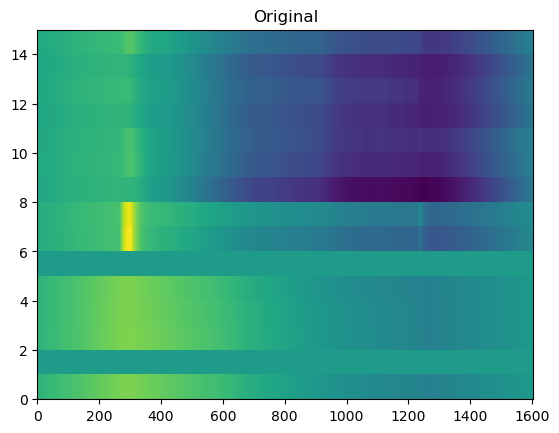

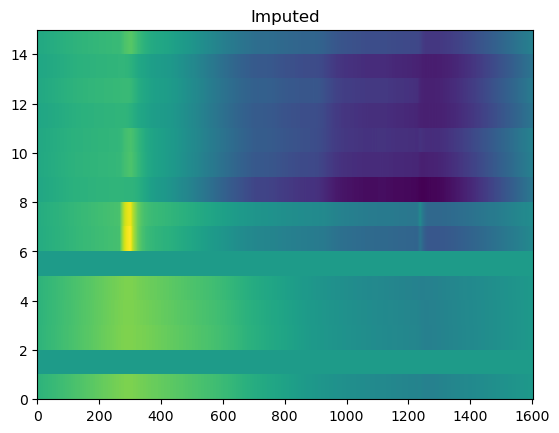

In [5]:
from sklearn.impute import SimpleImputer
import numpy as np

fig, ax = plt.subplots()
ax.pcolorfast(flux_loop.values)
ax.set_title("Original")

imp = SimpleImputer(missing_values=np.nan, strategy="mean")
vals = flux_loop.values
imp.fit(vals)
vals = imp.transform(vals)

fig, ax = plt.subplots()
ax.pcolorfast(vals)
ax.set_title("Imputed")

Get an array of flux loops across all shots. Perform imputation as above.

In [6]:
from multiprocessing import Pool

def process_shot_id(shot_id):
    """
    Process a single shot ID to get flux loop values, handle missing data, 
    and return the imputed array.

    Args:
        shot_id: The ID of the shot to process.

    Returns:
        Imputed numpy array of flux loop values for the given shot ID.
    """
    try:
        flux_loop = get_flux_loop(shot_id)
        vals = flux_loop.values
        
        imp = SimpleImputer(missing_values=np.nan, strategy="mean")
        imp.fit(vals)
        vals = imp.transform(vals)
        
        return vals
    except Exception as e:
        print(f"Error processing shot ID {shot_id}: {e}")
        return None


# Open magnetics profile for the first shot to initialize flux_loop_array
store = get_shot_fsstore(shot_ids[0])
profiles = xr.open_zarr(store, group="magnetics")
flux_loop_array = profiles["flux_loop_flux"].values


# [ROH] WARNING: Multi-thread processing is not supported on Windows Jupyter notebooks.
# Source: https://stackoverflow.com/a/67721198
pool_processing = False
if pool_processing:
    # Process each shot ID in parallel, excluding the first one which we already processed
    with Pool(processes=4) as pool:
        results = list(tqdm(
            pool.imap(process_shot_id, shot_ids[1:]),
            total=len(shot_ids[1:])
        ))
else:
    results = [process_shot_id(id_) for id_ in shot_ids[1:]]
    total = len(shot_ids) - 1

# Drop results where getting flux loop has failed
valid_results = [vals for vals in results if vals is not None]

# Concatenate the results
concatenated_array = np.concatenate(valid_results, axis=1)
flux_loop_array = np.concatenate((flux_loop_array, concatenated_array), axis=1)

flux_loop_array = flux_loop_array.T

Principal component analysis

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
pca.fit(flux_loop_array)

explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = 0

for i, val in enumerate(explained_variance):
    cumulative_explained_variance += val
    print(f"Principal component: {i+1}")
    print(f"Explained variance: {val:.3f}")
    print(f"Cumulative explained variance: {cumulative_explained_variance:.3f}\n")

Principal component: 1
Explained variance: 0.903
Cumulative explained variance: 0.903

Principal component: 2
Explained variance: 0.086
Cumulative explained variance: 0.989

Principal component: 3
Explained variance: 0.007
Cumulative explained variance: 0.996

Principal component: 4
Explained variance: 0.003
Cumulative explained variance: 1.000

Principal component: 5
Explained variance: 0.000
Cumulative explained variance: 1.000



Demonstrate PCA transform and reconstruction

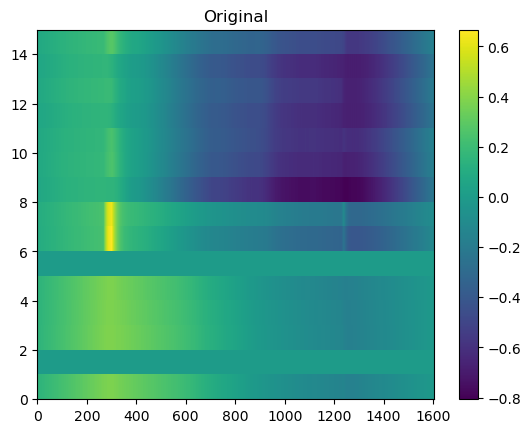

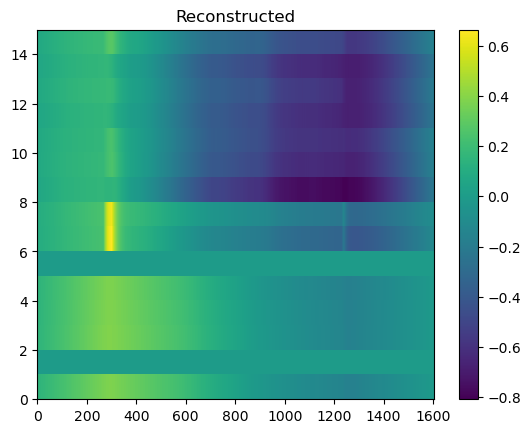

In [8]:
flux_loop = get_flux_loop(30471)
vals = flux_loop.values

imp = SimpleImputer(missing_values=np.nan, strategy="mean")
imp.fit(vals)
vals = imp.transform(vals)

transformed = pca.transform(vals.T)
reconstructed = pca.inverse_transform(transformed).T

fig, ax = plt.subplots()
ax.set_title("Original")
p = ax.pcolorfast(vals)
fig.colorbar(p, ax=ax)

fig, ax = plt.subplots()
ax.set_title("Reconstructed")
p = ax.pcolorfast(reconstructed)
fig.colorbar(p, ax=ax)